<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan5_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PERTEMUAN 5: VISUALISASI DATA**

## **Aktivitas Hands-on: Dashboard Visualisasi Statis**

### NAMA  : Febi Kristiana
### NIM   : 240401010231
### KELAS : IF403


# DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. LOAD & INSPECT DATASET
df = sns.load_dataset('tips')
print(" SHAPE & DATA TYPES ")
print(df.shape, "\n")
print(df.dtypes)
print("\n RINGKASAN STATISTIK ")
print(df.describe().round(2))

# Hitung agregasi untuk kebutuhan narasi angka
avg_day = df.groupby('day', observed=False)['total_bill'].mean().round(2)
total_records = len(df)
print("\n RATA-RATA TAGIHAN PER HARI ")
print(avg_day)

 SHAPE & DATA TYPES 
(244, 7) 

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

 RINGKASAN STATISTIK 
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

 RATA-RATA TAGIHAN PER HARI 
day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


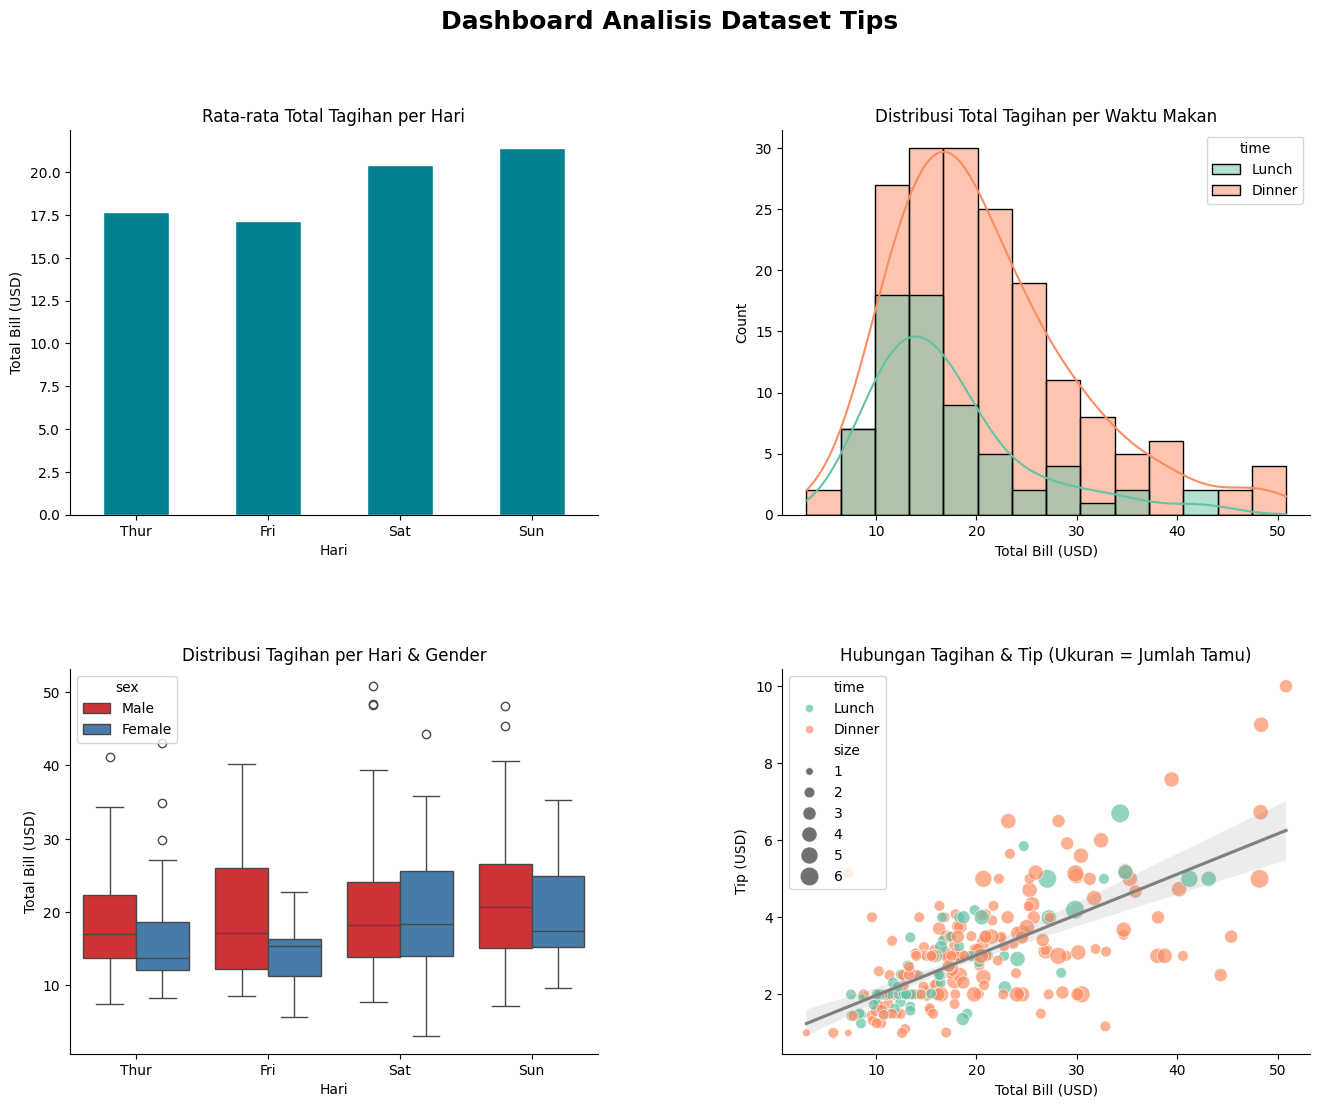

Dashboard berhasil diekspor dan tersimpan sebagai dashboard_tips.png


In [2]:
# SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# GRAFIK 1: Bar Chart
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# GRAFIK 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.set_xlabel('Total Bill (USD)')
ax2.spines[['top','right']].set_visible(False)

# GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top','right']].set_visible(False)

# GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size',
                sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top','right']].set_visible(False)

# EKSPOR GRAFIK
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard berhasil diekspor dan tersimpan sebagai dashboard_tips.png')

### 1. ANALISIS GRAFIK 1: Bar Chart

**Rata-rata Total Tagihan per Hari**
1. **What**: Grafik menunjukkan bahwa rata-rata total tagihan tertinggi terjadi pada hari Minggu sebesar sekitar \$21.41, diikuti hari Sabtu sebesar \$20.44. Sementara itu, rata-rata tagihan terendah terjadi pada hari Jumat sebesar \$17.15.
2. **So What**: Hasil ini menunjukkan bahwa pelanggan cenderung mengeluarkan lebih banyak uang pada akhir pekan dibandingkan hari kerja. Kondisi ini membuat pendapatan restoran lebih tinggi pada hari Sabtu dan Minggu.
3. **Now What**: Berdasarkan temuan tersebut, restoran dapat menyiapkan stok bahan makanan yang lebih banyak dan menambah jumlah staf pada akhir pekan untuk mengantisipasi meningkatnya jumlah pelanggan.

### 2. ANALISIS GRAFIK 2: Histogram + KDE

**Distribusi Total Tagihan per Waktu Makan**
1. **What**: Grafik distribusi menunjukkan bahwa total tagihan saat makan malam (*Dinner*) memiliki sebaran yang lebih luas dibandingkan makan siang (*Lunch*), dengan nilai tagihan yang dapat mencapai sekitar \$50. Sementara itu, sebagian besar tagihan saat makan siang mengelompok padat pada kisaran \$10 hingga \$30.
2. **So What**: Hasil ini menunjukkan bahwa pelanggan cenderung mengeluarkan uang lebih banyak saat makan malam dibandingkan saat makan siang. Dengan demikian, sesi makan malam memberikan kontribusi pendapatan yang lebih besar bagi restoran.
3. **Now What**: Berdasarkan temuan tersebut, restoran dapat membuat promo atau paket hemat untuk makan siang agar lebih banyak pelanggan datang dan penjualan pada jam makan siang dapat meningkat.

### 3. ANALISIS GRAFIK 3: Boxplot

**Distribusi Tagihan per Hari & Gender**
1. **What**: Grafik boxplot menunjukkan bahwa nilai median dari total tagihan pelanggan laki-laki secara konsisten lebih tinggi dibandingkan pelanggan perempuan di hampir seluruh hari, kecuali pada hari Jumat. Selain itu, ditemukan pencilan (*outliers*) ekstrem tertinggi dialami oleh pelanggan laki-laki di hari Sabtu yang mencapai \$50.81.
2. **So What**: Data ini mengindikasikan adanya perbedaan daya beli atau preferensi pemesanan menu yang dipengaruhi oleh profil gender konsumen di restoran tersebut, terutama pada akhir pekan.
3. **Now What**: Diperlukan analisis lanjutan terkait jenis menu atau item spesifik apa yang sering dipesan oleh kelompok pelanggan laki-laki pada hari Sabtu untuk dijadikan bahan acuan penjualan tambahan (*up-selling*).

### 4. ANALISIS GRAFIK 4: Scatter Plot

**Hubungan Tagihan dan Tip**
1. **What**: Grafik scatter plot menunjukkan adanya hubungan positif antara total tagihan dan jumlah tip yang diberikan pelanggan. Semakin besar total tagihan, semakin besar pula tip yang diterima. Selain itu, banyak transaksi bernilai tinggi terjadi pada waktu makan malam (*Dinner*) dan melibatkan kelompok pelanggan dengan ukuran rombongan yang lebih besar.
2. **So What**: Hasil ini menunjukkan bahwa besarnya tip yang diterima pramusaji dipengaruhi oleh nilai transaksi pelanggan. Semakin tinggi total tagihan, semakin besar peluang mendapatkan tip yang lebih tinggi.
3. **Now What**: Berdasarkan temuan tersebut, restoran dapat memberikan pelatihan kepada pramusaji untuk meningkatkan kualitas pelayanan dan kemampuan menawarkan menu tambahan (*suggestive selling*), sehingga pelanggan lebih tertarik untuk melakukan pembelian dengan nilai yang lebih besar.

## KESIMPULAN

### Apa yang Dipelajari
Pada Pertemuan 5, saya belajar membuat dashboard visualisasi menggunakan Matplotlib & Seaborn untuk merangkum pola data.

### Temuan Utama
1. Grafik menunjukkan tren berdasarkan waktu/hari.
2. Hubungan antar variabel terlihat jelas dari scatter/boxplot.

### Keterbatasan (Singkat)
Dashboard masih bersifat statis, sehingga interpretasi sangat bergantung pada narasi yang dibuat.
